# Assignment 03: Implementing Linear Regression and Gradient Descent from Scratch (example solution)
---

**Due Date:** Friday 10/03/2025 (by midnight)

**Please fill these in before submitting, just in case I accidentally mix up file names while grading**:

Name: Jane Hacker

CWID-5: (Last 5 digits of cwid)

## Introduction 

Welcome to our assignment on implementing linear regression and gradient descent from scratch.  In this assignment you will
build, in Python, functions you need to perform a linear regression optimization by hand.  This includes implementing the
functions to calculate predictions given a set of weights for a model (they model hypothesis), the root mean squared error (RMSE) cost function, which we will use
to determine the "goodness" of solutions, and the gradients of model weights with respect to this
cost, so that you can perform simple gradient descent optimization.

It is useful to build basic linear and logistic regression implementations by hand, at least once, to help you build up your intuition
of how parametric models like linear and logistic regression actually work, and how optimization using a model's gradients
is performed.


**Instructions**:

- You need to use the class development environment and make sure that you are pushing your assignments to your
  GitHub classroom and they are successfully passing the autograder.
- Avoid using for-loops and while loops, unless you are explicitly told to do so in the assignment task functions for this assignment.
- Do not modify the `### TESTED FUNCTION [function name]` cells.  These cells call unit tests on the functions
  you are asked to write for these assignments.
- All functions you need to write should be placed into the `src/assginment_tasks.py` file.  Functions that are
  tested and graded are imported from there into this notebook.
  - You have not been given function documentation and stub functions for this and future assignment.  You need to
    add in the function declarations and uncomment the code to import and test your functions.
  - You are required to give NumPy style formated Pydoc documentation for your functions.
- After coding your function, run the `### TESTED FUNCTION` cell to determine if it is passing the assignment
  unit tests and that your result is correct.

**After this assignmeent you will**:

- Know how to build the general architecture of a learning algorithm for a parametric model, including:
  - Initializing parameters
  - Calculating the cost function and its gradient
  - Using an optimization algorithm (gradient descent)
- Gather all of the above functions into a main model function, in the right order, to perform linear regression on a set of data.

Let's get started!

In [1]:
# The following ipython magic will reload changed file/modules.
# So when editing function in source code modules, you should
# be able to just rerun the cell, not restart the whole kernel.
%load_ext autoreload
%autoreload 2

In [2]:
# assignment wide imports go here, usually all of your imports for noteboosk should
# be put up at the top here, if they were not given to you at the start of the assignment
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import seaborn as sbn

In [3]:
# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from assg_utils import run_unittests, run_doctests
from assg_tasks import load_onefeature_dataset
from assg_tasks import load_multifeature_dataset
from assg_tasks import add_dummy_feature
from assg_tasks import predict
from assg_tasks import loss_grad
from assg_tasks import gradient_descent

In [4]:
# assignment wide settings
np.set_printoptions(suppress=True)
matplotlib.rcParams['figure.figsize'] = (12, 8)

## Task 1: Overview of the Problem Set and adding a Dummy Feature

To start with for this assignment, lets load a dataset that has a single input feature.  This dataset has
$n = 47$ samples, and a single feature $m = 1$ is given.  This is a somewhat artifical dataset that has several
features, but we are only working with a single feature to begin with for this assignment.  The dataset has already
been scaled using a standard scaler.

In [5]:
x, y_true = load_onefeature_dataset()

**Task**: As a warm up, confirm and display the number of samples and number of features in the dataset we are using to start with.  By convention in this class we
use $n$ to indicate the number of samples in a dataset, and $m$ for the number of features.  So you should find that the training data is
an array of shape `(n, m)` with 47 rows for the 47 samples, and 1 column feature.   Assign `n` and `m` python variables the values of the
number of samples and number of features we are using, for use in the next assignment tasks below.

In [6]:
n, m = x.shape
print('Number of samples:', n)
print('Number of features:', m)

Number of samples: 47
Number of features: 1


**Task**: Also lets visualize this first dataset in the next cell using a scatter plot.

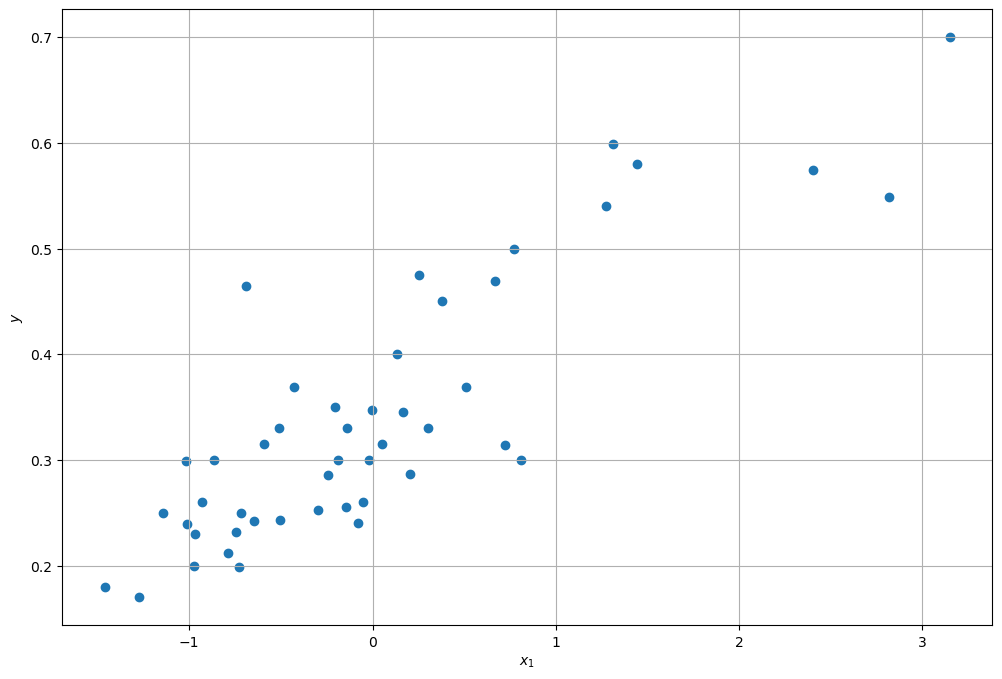

In [7]:
# visualize the dataset
plt.scatter(x, y_true)
plt.xlabel(f'$x_1$')
plt.ylabel(f'$y$');
plt.grid();

**Task**: We will explain why in a moment, but we actually need to add in a dummy feature to the dataset you have been given.  The initial
dataset has a single column/feature.  Create a function named `add_dummy_feature()` that takes an array of shape `(n, m)` as input and returns
a new array of shape `(n, m+1)`.  It should do this by adding a new column 0 as the first column of the array.  The column should have
all dummy values of 1.0 for this dummy feature.

In [8]:
#### TESTED FUNCTION add_dummy_feature()
run_unittests(['test_add_dummy_feature'])

x = add_dummy_feature(x)
print('x shape:', x.shape)
print('x first 5 samples:')
print(x[:5])

test_given_case (test_assg_tasks.test_add_dummy_feature.test_given_case)
test_given_case ... ok
test_random_case (test_assg_tasks.test_add_dummy_feature.test_random_case)
test_random_case ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.112s

OK


x shape: (47, 2)
x first 5 samples:
[[ 1.          0.13141542]
 [ 1.         -0.5096407 ]
 [ 1.          0.5079087 ]
 [ 1.         -0.74367706]
 [ 1.          1.27107075]]


You have completed the first task.  Make sure that you make a commit of your work that passes the tests for this task and push it to your GitHub classroom.

<font color='blue'>
    
**What to remember:**

- In this assignment (and the class in general) we usually refer to a dataset as having `(n, m)` size, whith $n$ input samples, each sample consisting of $m$ features.
- For this assignment, we will add a dummy feature, so our models will have $m + 1$ features to accomodate the $\theta_0$ dummy parameter that models the intercept term for our linear models.

**Expected Output**: You should expect that the `x` regression data now has shape `(47, 2)` and that the dummy feature column 0 has all 1.0 values.

## Task 2: Model Prediction

**Model Prediction**

In its simplest form a linear regression is a search for parameters to fit the best possible line, with the lowest cost, to a set of data.  The equation
of a line where we have one feature variable $x$ is

\begin{equation}
\hat{y} = b + \theta x
\end{equation}

Where $b$ is the intercept term of the line and $\theta$ is the slope or weight parameter of the line.  If you think of this equation as always having a dummy parameter that is always 1 
(like you added in the previous function you implemented), we could generalize this a bit like this:

\begin{equation}
\hat{y} = \theta_0 x_0 + \theta_1 x_1
\end{equation}


Here the $x_0$ is a dummy feature that always has a value of 1, so $\theta_0$ corresponds to the intercept term of the first equation, and $\theta_1$ is the slope term for our feature that
we now call $x_1$.  And where we originally had $m = 1$ features, we now have $m = m+1 = 2$ features in the dataset we will be trying to fit a model of.

We updated the equation of the line with a single feature like this, because this general form can be extended to a linear model for any number $m$ of features, like this:

\begin{equation}
\hat{y} = \theta_0 x_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_m x_m
\end{equation}

Where here $x_0$ is the dummy feature for our intercept term, and each of the $\theta_1$ through $\theta_m$ are the weight or slope parameters for each of the features $x_1 \dots x_m$

If we think of $\theta$ and $x$ as vectors of $m$ slope values and features:

\begin{equation}
\theta =
  \begin{bmatrix}
  \theta_0 \\
  \theta_1 \\
  \vdots \\
  \theta_m
  \end{bmatrix}
x =
  \begin{bmatrix}
  x_0 \\
  x_1 \\
  \vdots \\
  x_m
  \end{bmatrix}
\end{equation}

Then the vector multiplication (dot product) of $x$ and $\theta$ is equivalent to the sum of the products of the individual elements:

\begin{align}
\hat{y} &= \theta_0 x_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_m x_m \\
        &= \sum_{j=0}^{m} \theta_j x_j \\
        &= x \cdot \theta
\end{align}

And further, if instead of a single input sample of $m$ features, $x$, we have a matrix $X$ (we usually use capital letters to denote
matices), the above still works. Lets say that $X$ is a matrix of shape `(n, m)`, meaning it has $n$ input samples, each with $m$ features.
The matrix multiplication of the `(n, m)` shaped matrix $X$ by the weight
vector $\theta$ will now still work $X \cdot \theta$, and will result in $n$ predictions, one for each of the $n$ inputs of the $X$ data matrix.

Just to make sure you understand this, lets say that we have a set of $\theta$ parameters.  We will just start with $\theta$ set to some random values.
The initial dataset you have been given has a single actual feature, so there are actually 2 columns of data after you added in the dummy feature column.
So $n = 47$ because we have 47 individual sample rows, and $m = 2$ because we have a dummy feature of all 1's in the first column, and the second column is the
first actual feature, the size in square feet of the houses in the data.

In [9]:
# there are "2" features, so create a set of 2 random theta weight parameters
theta = np.random.random((2,))
theta.shape

(2,)

In [10]:
# what is the prediction given this "random" model for the 5th sample of our data?
y_pred = x[4] @ theta
print(y_pred)

0.6454537447476204


In [11]:
# let's generate all predictions for our current random model, and show first 5 predictions
y_pred = x @ theta
print(y_pred.shape)
print(y_pred[:5])

(47,)
[ 0.17835812 -0.08438318  0.33266649 -0.1803046   0.64545374]


What we have developed so far is the formal method for making predictions given a model $\theta$.  You don't know how to fit the model $\theta$
parameters yet, but if someone tells you that these set of parameters is the best fit line, you can make predictions $\hat{y}$ or `y_pred` for any single or
set of input data needed.

**Task**: Lets start by first implementing a function named `predict()`.  This model takes a set of input data `X` of shape `(n, m)` with $n$ samples and $m$ features.
It also takes a vector that represents a model that we will call `theta`.  A dummy feature will have already been added before calling the functions you write in this
section, so if there were originally $m$ features, the data to be evaluated and the number of parameters in `theta` will actually be of size $m + 1$.

This model returns `y_pred` which will be a NumPy vector of shape `(n,)`, which are the predictions for each of the input samples of `X` given the current
model `theta`.

Your `predict()` function should be relatively straightforward if you have followed the discussion above for how to implement it.  You are required to
give vectorized implementations of `predict()` here, you should not be using any loops to calculate the predictions for all of the input samples given
in `X`.

In [12]:
#### TESTED FUNCTION predict()
run_unittests(['test_predict'])

# create a set of theta values to test predictions with
theta = np.array([0.34, 0.10])
y_pred = predict(x, theta)
print('y_pred shape:', y_pred.shape)
print('y_pred values')
print(y_pred)

test_given_case (test_assg_tasks.test_predict.test_given_case)
test_given_case ... ok
test_identity_case (test_assg_tasks.test_predict.test_identity_case)
test_identity_case ... ok
test_random_case (test_assg_tasks.test_predict.test_random_case)
test_random_case ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.005s

OK


y_pred shape: (47,)
y_pred values
[0.35314154 0.28903593 0.39079087 0.26563229 0.46710707 0.33800549
 0.28064115 0.26703142 0.26105332 0.2755534  0.33228178 0.3399134
 0.3259221  0.65509933 0.24680763 0.3780715  0.2534217  0.24273743
 0.41737435 0.47105008 0.31027727 0.32566771 0.2895447  0.33508004
 0.58030944 0.22543909 0.27097443 0.40681727 0.36535213 0.42093577
 0.31943522 0.21271973 0.34500115 0.48453261 0.3158738  0.26830336
 0.24311901 0.35670297 0.62164739 0.36051878 0.29717633 0.37018549
 0.41203221 0.23815846 0.19389506 0.32108874 0.23854004]


**Expected Output** Given the values of the `theta` model in the test for this cell, you should get the following output from
your `predict()` function:

```
y_pred shape: (47,)
y_pred values
[0.35314154 0.28903593 0.39079087 0.26563229 0.46710707 0.33800549
 0.28064115 0.26703142 0.26105332 0.2755534  0.33228178 0.3399134
 0.3259221  0.65509933 0.24680763 0.3780715  0.2534217  0.24273743
 0.41737435 0.47105008 0.31027727 0.32566771 0.2895447  0.33508004
 0.58030944 0.22543909 0.27097443 0.40681727 0.36535213 0.42093577
 0.31943522 0.21271973 0.34500115 0.48453261 0.3158738  0.26830336
 0.24311901 0.35670297 0.62164739 0.36051878 0.29717633 0.37018549
 0.41203221 0.23815846 0.19389506 0.32108874 0.23854004]
```

**Task**: For the previous example of your `predict()` method, we used values of the `theta` parameters that are close to the best
fitting model line for this set of data.  We have to yet figure out how to build the optimization method to find the best set
of `theta` for some data.  But to double check, in the next cell, replot the `x` training data as a scatter plot, and plot the
predicted values as a line on the plot.  It should verify that the `theta` parameters you just used to test your funciton look
like a pretty good fitting line to the data.

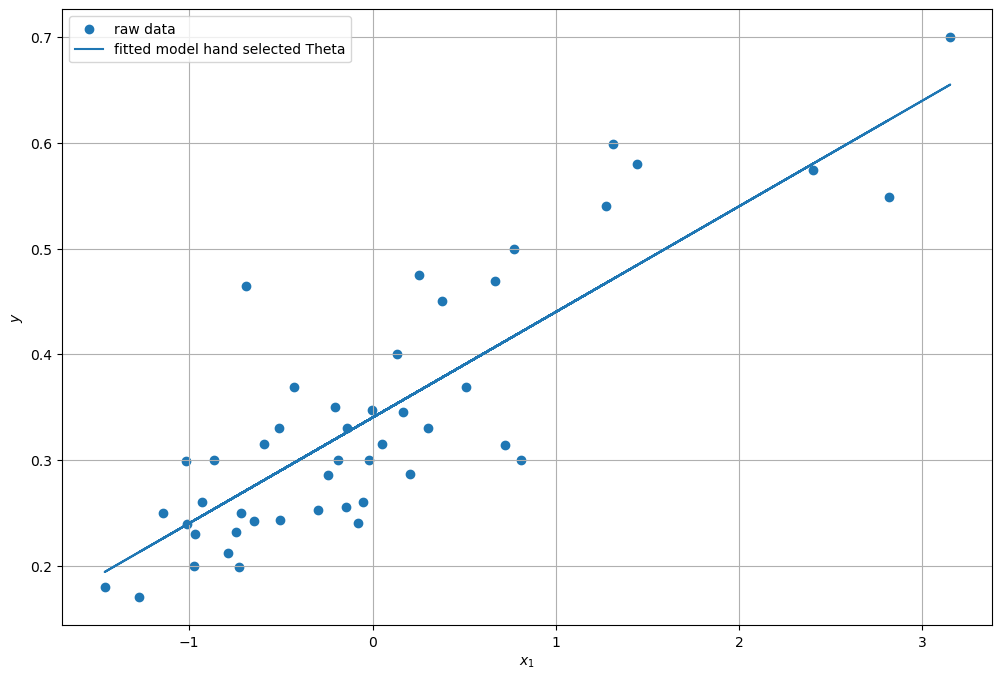

In [13]:
plt.scatter(x[:,1], y_true, label='raw data')
plt.plot(x[:,1], y_pred, label='fitted model hand selected Theta');
plt.xlabel(f'$x_1$')
plt.ylabel(f'$y$');
plt.grid();
plt.legend();

Once you have completed task 2, commit your working version of your `predict()` function and push it to your GitHub classroom.

<font color='blue'>
    
**What to remember:**

- We will use a variable named `y_pred` to indicate the predictions made from a model, which in our formalization above is referred to as $\hat{y}$, and can be calculated
  using a simple matrix/vector dot product $X \cdot \theta$
- The true values will be referred to as `y_true` in Python, and we use the simple notation $y$ for the true values in the formalization above.

## Task 3: Model Loss

**Linear Regression Loss Function**

To fit a linear model we need some measure of how good of a "fit" a set of parameters $\theta$ is.  For linear regression we typically use the mean squared error **MSE** 
as our loss function $L$, which you have seen before:

\begin{equation}
L(\theta) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}^{(i)} - y^{(i)})^2
\end{equation}

**Note** The loss is over the $n$ input samples, so we sum over $n$ here, which is different from the model predictions which is a sum over the multiplication of each of the $m + 1$
features of a sample.

Here $\hat{y}^{(i)}$ is the predicted output for the $i^{th}$ sample given the current model parameters $\theta$ (e.g. your previous funciton to
calculate the predictions `y_pred` given a set of model weights).
And $y^{(i)}$ is the true value labels `y_true` for the $i^{th}$ sample.  Finally we divide by $n$ here to get the mean of the sum of the
squared errors.

Also as we have noted before, if you define a vector $\text{error} = \hat{y} - y$, which is the resulting vector of the difference
of each prediction from its true value, we can easily implement the MSE by performing the dot product of the $\text{error}$ with
itself, which will have the same effect of squaring and summing up the errors.

For efficiency, since we need to reuse the results of calling predict and calculating the errors between the predictions and the true labels, we are going
to write a single function in task 3 that computes both the loss and the gradients with respect to the loss in a single function.  So lets also discuss
how to formally calculate the gradients of the MSE loss function.

**Gradients of Model with respect to Loss**

You need one more equation in order to implement gradient descent so that we can determine what are the best set of
$\theta$ parameters that will minimize the loss function for a linear model.  For this you need to be able to determine the
**derivative**, or **gradient**, of the loss function with respect to the model parameters $\theta$.  The gradients of the
loss with respect to $\theta$ is:

\begin{equation}
\frac{\partial}{\partial \theta_j} L(\theta) = \frac{2}{n} \sum_{i=1}^{n} \big( \hat{y}^{(i)} - y^{(i)} \big) x_j^{(i)}
\end{equation}

To be a bit more concrete, notice that the equation of the partitial derivative is with respect to each of the features $0 \dots m$ here.
We can actually calculate the gradients with respect to each of the features in a single vectorized operation as follows:

$$
\nabla_{\theta} \text{L}(\theta) = 
\begin{pmatrix}
\frac{\partial}{\partial \theta_0} \text{L}(\theta) \\
\frac{\partial}{\partial \theta_1} \text{L}(\theta) \\
\vdots \\
\frac{\partial}{\partial \theta_m} \text{L}(\theta) \\
\end{pmatrix}
= \frac{2}{n} X^T (\hat{y} - y)
$$

Don't get too hung up on the notation here.  Notice the final form of the last equation here.  The $(\hat{y} - y)$ is again the errors, or the difference between the
predictions and the true values.  And $X^T$ is just the transpose of the $X$ set of data we are training and predicting with.  But in short, the final form of the equation
should give you what you need to calculate the gradients with respect to the theta loss predictions for this task.

**Task**: Implement a function named `loss_grad()`.  This function
will reuse your `predict()` method, so we will pass in the same parameters as before: `X` input data of shape
`(n, m)` with $n$ input samples each consisting of $m$ features, and a model `theta` parameters which is a vector of shape `(m,)`.  But
in addition, the `y_true` values that the model is predicting also need to be passed in for this function.

This function will calculate the `loss` using the MSE expression given above.  You are required to reuse your `predict()`
method to get the predictions of the model on the input data.  As a suggestion and for efficiency, it is best to
calculate the vector of `errors`, since you can reuse these both to get the `loss` and in the calculation of the feature `gradients`.

Calculate the MSE loss using the expression given previously.  Make sure you calculate and return the average (mean) of the sum of the
squared losses.

Also calculate the gradients using the expression above.  You should be able to do both of these in a vectorized way, don't use any loops.
For the gradients, if you have the `errors`, you can calculate all of the gradients for the $m$ parameters using the final shown
expression.  Again don't forget the $\frac{2}{n}$ term of the gradients.

Your function should return a tuple of values `(loss, gradients)`. The `loss` is a single scalar of the average of the sum squared error
predictions of the `theta` model parameters applied to the input data.  The `gradients` is a vector of shape
`(m,)` of the gradient of the loss with respect to each of the $m$ model features.

In [14]:
#### TESTED FUNCTION loss_grad()
run_unittests(['test_loss_grad'])

# create a set of theta values to test predictions with
theta = np.array([0.0, 0.0])
loss, gradients = loss_grad(x, theta, y_true)
print('loss:', loss)
print('gradients.shape:', gradients.shape)
print('gradients:')
print(gradients)

test_given_case (test_assg_tasks.test_loss_grad.test_given_case)
test_given_case ... ok
test_optimal_case (test_assg_tasks.test_loss_grad.test_optimal_case)
test_optimal_case ... ok
test_random_case (test_assg_tasks.test_loss_grad.test_random_case)
test_random_case ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.005s

OK


loss: 0.13118309621291488
gradients.shape: (2,)
gradients:
[-0.68082532 -0.21152827]


**Expected Output** Given an initial set of 0 for the theta parameters, the following should be the loss and gradients with respect to the loss
for the regression data being used in this example:

```
loss: 0.1311830962129149
gradients.shape: (2,)
gradients:
[-0.68082532 -0.21152827]
```

**Task**: You already have been told from tasks above that the optimal intercept term `theta[0]` occurs about when `theta[0] = 0.34`.
Lets recreate the demonstration shown in class for the current `loss_grad()` function you have.  Hold `theta[0]` constant at `0.34`, but
vary the `theta[1]` term from -1.0 to 1.0 (use `np.linspace` and a sufficient number of points to generate a smooth curve).  Plot the loss
as `theta[1]` varies over that range.  You should see that it shows the expected convex curve, and the minimum occurs somewhere around `0.1`.

**Note**: Your `grad_loss()` function can only accept a single set of `theta` parameters in a call, so you will need to create a loop and gather the
the loss as it varies over the described range here.

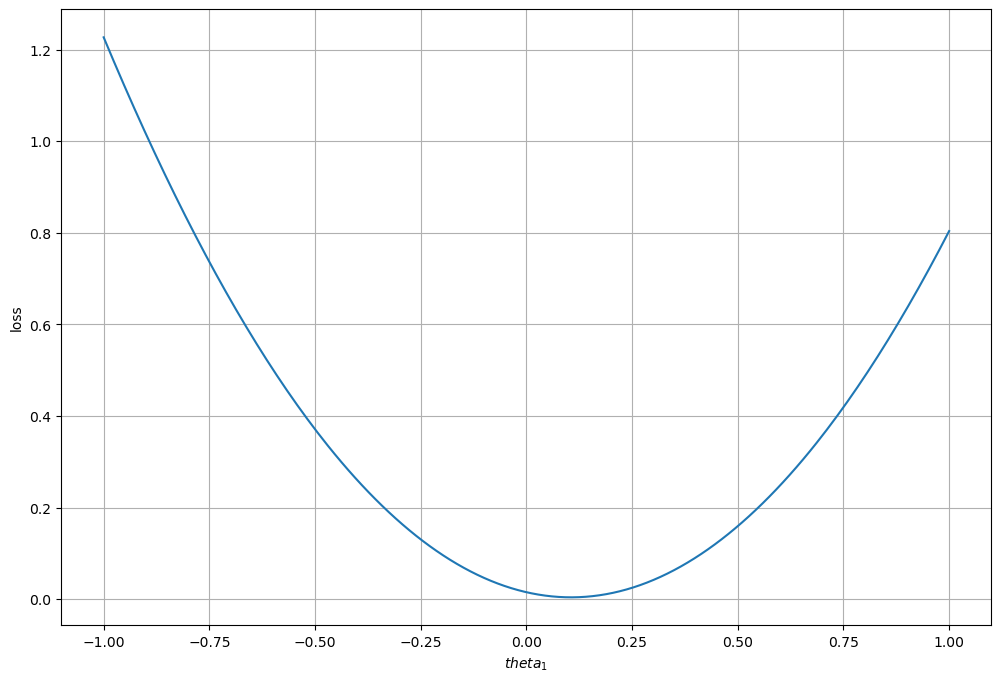

In [15]:
# first use our function to generate loss as a function of varying theta[1] from
# -1 to 1
theta_1 = np.linspace(-1, 1, 250)
loss = np.empty(250)
for i, t in enumerate(theta_1):
    theta = np.array([0.34, t])
    l, _ = loss_grad(x, theta, y_true)
    loss[i] = l

# now plot resulting loss
plt.plot(theta_1, loss)
plt.xlabel(f'$theta_1$')
plt.ylabel(f'loss')
plt.grid();


In [16]:
# most students use an iterative approach, but the predict() and loss_grad() functions are vectorized,
# so we can perform vectorized operations and calculate all losses for all theta like this
# create an array shape (2,250) of all of the theta parameters we want to calculate loss for
theta_0 = np.ones(250) * 0.34
theta_1 = np.linspace(-1, 1, 250)
theta = np.stack([theta_0, theta_1])
print(theta.shape)

# a little bit tricky/kludgy but if implemented predict() and loss_grad() as described, we need the y_true values to
# be shape (n,1) instead of a vector, so that the broadcasting works correctly in numpy
print(x.shape)
y_true_col = y_true.reshape(n, 1)
print(y_true_col.shape)

# given this theta and x and reshaped y_true as a column vector, your loss_grad should work in a vectorized way
loss, gradients = loss_grad(x, theta, y_true_col)
print(loss.shape)

(2, 250)
(47, 2)
(47, 1)
(250,)


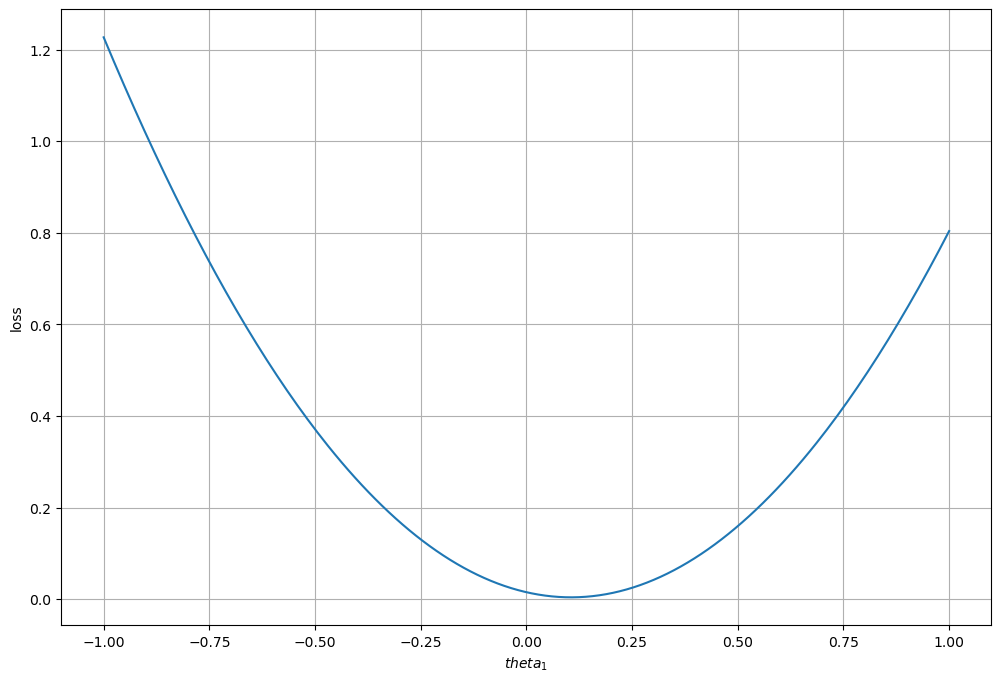

In [17]:
# now plot resulting loss
plt.plot(theta_1, loss)
plt.xlabel(f'$theta_1$')
plt.ylabel(f'loss')
plt.grid();

In [18]:
y_pred = predict(x, theta)
print(y_pred.shape)
errors = (y_pred - y_true_col)
print(errors.shape)
loss = np.sum(errors**2.0, axis=0) / n
print(loss.shape)
gradients = (x.T @ errors) * (2.0 / n)
print(gradients.shape)

(47, 250)
(47, 250)
(250,)
(2, 250)


Don't forget to commit your working task 3 function and push it to your repository now.

<font color='blue'>
    
**What to remember:**

- You can think of the errors for a single sample as `error = y_pred - y_true`.  If `y_pred` and `y_true` are vectors of $n$ predictions and true values, than the vectorized difference
  of those is also of size $n$ and contains the errors or differences between each prediction and its the true value that should be predicted for the $i^{th}$ sample.
- The average of the sum of the squares of the errors is known as the mean squared error **MSE** and will be used as our loss function to measure how well on average a liner model does in predicting the true values
  of a set of data.
- The gradients with respect to some model $\theta$ can be calculated by multiplying the inputs times the errors.  The expression given above is derived by symbolically taking the
  derivative of the $L$ loss function.

## Task 4: Gradient Descent

You now have all of the pieces in order to implement a simple gradient descent optimization of a linear regression model.

The pseudo-code you will implement for your hand coded gradient descent is as follows:

```
Initialize a vector of `theta` parameters of an appropriate size, initialize all values to 0
 
for a fixed number of epochs
    calculate the current loss and gradients for theta
    update theta using the gradients and a learning rate

return the final optimized theta
```

**Task**: Write a function called `gradient_descent()`.  This function takes the `X` inputs we are fitting a model to and the `y_true` labels.
There should also be two additional parameters with default values:

- `num_iter` default this to 50 iterations of gradient descent
- `eta` the learning rate to use, default to an `eta` learning rate of `0.1`

A dynamic gradient descent would usually try to detect when the loss has stopped changing sufficiently to determine
when to stop iterating values of `theta`.  We will leave this as an exercise to the interested student for now and
for this assignment you only need to perform the simpler method of iterating a fixed number of times, determined
by the `num_iter` parameter of this function.

The formal update rule for gradient descent is usually given as:

\begin{equation}
\theta = \theta - \eta \text{ } d\theta
\end{equation}

Here $\eta$ or `eta` is usually used to denote the learning rate for the gradient descent, and as mentioned should have
a default learning rate of `0.1` for your function.  $\text{ } d\theta$ is simply the derivitives or in other words the
gradients of $\theta$ `theta`.  So this simply says that, to update theta for the next iteration, simply subtract `eta` times
the gradients from the current `theta` to get the next `theta` to use.

You might want to take a moment and make sure you understand why this update rule for gradient descent works.  Basically the
gradients with respect to `theta` give the slope of the function.  If the slope is negative, we should add some amount to `theta` to
go towards a lower loss value.  If the slope is positive, we should subtract.  By taking the $- \eta \text{ } d\theta$ we actually add or
subtract from `theta` as needed based on the slope specified in the gradients.  The learning rate $\eta$ is there so that we can specify how
big or small of a step along the gradient we should take.  The number of iterations to perform, and the size of the learning rate steps, are both
meta parameters that may need to be adjusted in order to get gradient descent to converge successfully for some set of data being modeled.

As a final requirement for your `gradient_descent()` function, in addition to returning the final `theta` after gradient descent is performed for
the specified number of iterations, we also need to pass back an array of the history of the `loss` values obtained for each gradient descent
step.  So you should also create a numpy array in your function, and append each `loss` value to this array and return it from your function. An alternative
approach is to start with a regular Python list, append each value to the list, then convert the list into a numpy array to return it.  The tests expect
that a numpy array is returned with the history from this function.

**Note**: it is expected, as the pseudo-code given implies, that you use explicit iteration in your `gradient_descent()` implementation.

In [19]:
#### TESTED FUNCTION predict()
run_unittests(['test_gradient_descent'])

# do gradient descent, using default number of iterations of 50 and learing rate eta of 0.1
theta, history = gradient_descent(x, y_true)

print('theta shape:', theta.shape)
print('theta:')
print(theta)
print('loss history:')
print(history)

test_given_case (test_assg_tasks.test_gradient_descent.test_given_case)
test_given_case ... ok

----------------------------------------------------------------------
Ran 1 test in 0.003s

OK


theta shape: (2,)
theta:
[0.3404078  0.10576262]
loss history:
[0.1311831  0.08543904 0.05616284 0.03742607 0.02543454 0.01775996
 0.01284823 0.00970472 0.00769288 0.0064053  0.00558125 0.00505385
 0.00471632 0.0045003  0.00436205 0.00427357 0.00421694 0.0041807
 0.0041575  0.00414266 0.00413316 0.00412708 0.00412318 0.00412069
 0.0041191  0.00411808 0.00411743 0.00411701 0.00411674 0.00411657
 0.00411646 0.00411639 0.00411635 0.00411632 0.0041163  0.00411629
 0.00411628 0.00411627 0.00411627 0.00411627 0.00411627 0.00411627
 0.00411627 0.00411627 0.00411627 0.00411627 0.00411627 0.00411627
 0.00411627 0.00411627]


**Expected Output** For the one feature dataset, given 50 iterations of training and a learing rate of 0.1, you should get the following final `theta`
and `loss` history results:

```
theta shape: (2,)

theta:
[0.3404078  0.10576262]

loss history:
[0.1311831  0.08543904 0.05616284 0.03742607 0.02543454 0.01775996
 0.01284823 0.00970472 0.00769288 0.0064053  0.00558125 0.00505385
 0.00471632 0.0045003  0.00436205 0.00427357 0.00421694 0.0041807
 0.0041575  0.00414266 0.00413316 0.00412708 0.00412318 0.00412069
 0.0041191  0.00411808 0.00411743 0.00411701 0.00411674 0.00411657
 0.00411646 0.00411639 0.00411635 0.00411632 0.0041163  0.00411629
 0.00411628 0.00411627 0.00411627 0.00411627 0.00411627 0.00411627
 0.00411627 0.00411627 0.00411627 0.00411627 0.00411627 0.00411627
 0.00411627 0.00411627]
```

**Task**: Lets explore a bit further your gradient descent implementation.  First of all, lets confirm that the optimization converged
on approximately the optimal parameters for the fitted line here.  In the following cell, us the `numpy` `polyfit()` method, that you have
seen used in class, to fit a linear (degree 1) model to the data.  

**Note**: `polyfit()` does not expect any dummy feature columns for how it works, so you should only pass in the actual feature column
when you call `polyfit()` here.

**Note**: `polyfit()` returns its fitted parameters from last to the 0th, so they will normally be in reverse of what we do here, or how
`scikit-learn` normally orders the fitted parameters.

You should find that the optimal parameters found by your back propagation implementation pretty much match those returned by `polyfit()`
(to 4 or 5 decimals at least).

In [20]:
polyfit_theta = np.polyfit(x[:,1], y_true, 1)
print(polyfit_theta)
print(theta)

[0.10576413 0.34041266]
[0.3404078  0.10576262]


**Task**: Lets look at the learning curve history of your gradient descent.  In the next cell, plot the history of the loss over the epochs
1-50 that your function performed.

**Note**: You should find that the loss decreased rapidly in the first 10-20 epochs, from above 0.12 to approaching 0.005.  A bit before epoch
20 the loss will begin slowing down significantly.

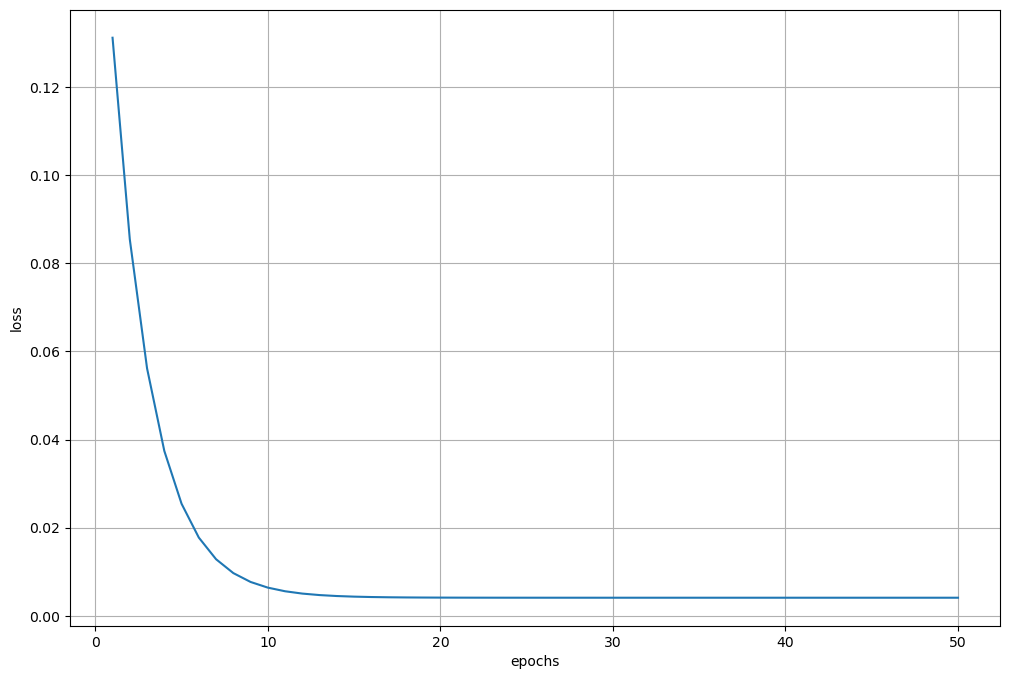

In [21]:
epochs = np.arange(1,51)
plt.plot(epochs, history)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid();

**Task**: Finally, lets again plot the fitted model line you obtained from your gradient descent on a scatter plot of the fitted data.
This is similar to what you did before.  But however, this time, note that for a linear regression, the resulting model is a line.
Previously you probably just plotted all of the predicted points from your `predict()` function of all of the inputs `x`, which will
fall on a line for our linear model.  Instead this time, create an array of 2 new x points, one at the minimum value of the feature 1 of the data, and
1 at the maximum value.  Then plot your line only using these two points, from the minimum to the maximum point of the original data.

**Hint**: You need a new array of only 2 new input `x` points, and you should reuse your `predict()` model and your `theta()` parameters to calculate the
predicted `y` location of the new `x` inputs.  Though also since your `predict()` method expects an array with a dummy feature column of 1, you also should
demonstrate reusing your `add_dummy_feature()` as well here to your new set of `x` inputs.

**Hint**: Don't forget the scatter plot of the original data points the model is fit to in the plot as well.

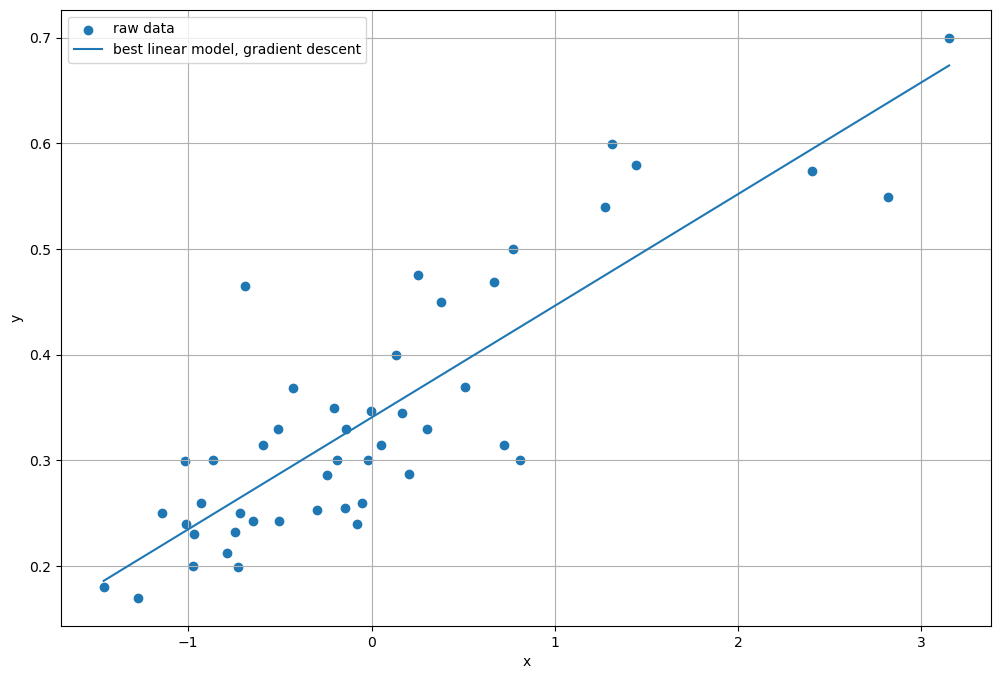

In [22]:
new_x = np.array([x[:,1].min(), x[:,1].max()]).reshape(-1,1)
new_x = add_dummy_feature(new_x)
y_pred = predict(new_x, theta)

plt.scatter(x[:,1], y_true, label='raw data');
plt.plot(new_x[:,1], y_pred, label='best linear model, gradient descent')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend();

Task 4 is complete.  Make sure all cells in the notebook are running cleanly, and create a commit with your working `gradient_descent()` funciton
and push to your GitHub classroom repository.

<font color='blue'>
    
**What to remember:**

- Gradient descent optimization is done by updating the `theta` parameters using infromation from the gradients, the slope of the
  function with respect to each dimension.
- Gradient descent is an iterative method, small steps of `theta` are used to follow the gradient to the minimum loss.
- Gradient steps are updated using a learning rate, often called `eta` in the literature.


## Task 5: Multifeature Linear Regression

For a final test, there are actually multiple features available in the test dataset we have been using.  The following cell loads
the full multifeature dataset, which still has $n = 47$ data samples, but there are 3 new features in addition to the single feature you have
been using up to this point.


In [23]:
x, y_true = load_multifeature_dataset()

**Task**: In the next cell, use your function to add in the dummy feature column, confirming that it works
for arrays with more than a single feature column.

Also in this next cell, confirm that the new array `x` does indead have 47 samples of 5 features now, which includes the new dummy feature column.

In [24]:
x = add_dummy_feature(x)
print(x.shape)

(47, 5)


Your implementations of `predict()`, `loss_grad()` and `gradient_descent()` should work with more than a single feature and a dummy feature, without
any modification, assuming you implemented them using numpy/vector operations as described.

**Task**: Fit a linear regression model to this multifeature dataset. There will now be 5 `theta` parameters that result from the fit.  We will no longer be able to
visualize the fit of the model since it is in a 4 dimensional space.

Once you fit the multifeature data, display the resulting theta parameters, and plot the loss history curve.

In [25]:
theta, history = gradient_descent(x, y_true)

In [26]:
theta

array([ 0.3404078 ,  0.11158775, -0.00863804, -0.01382482,  0.00662092])

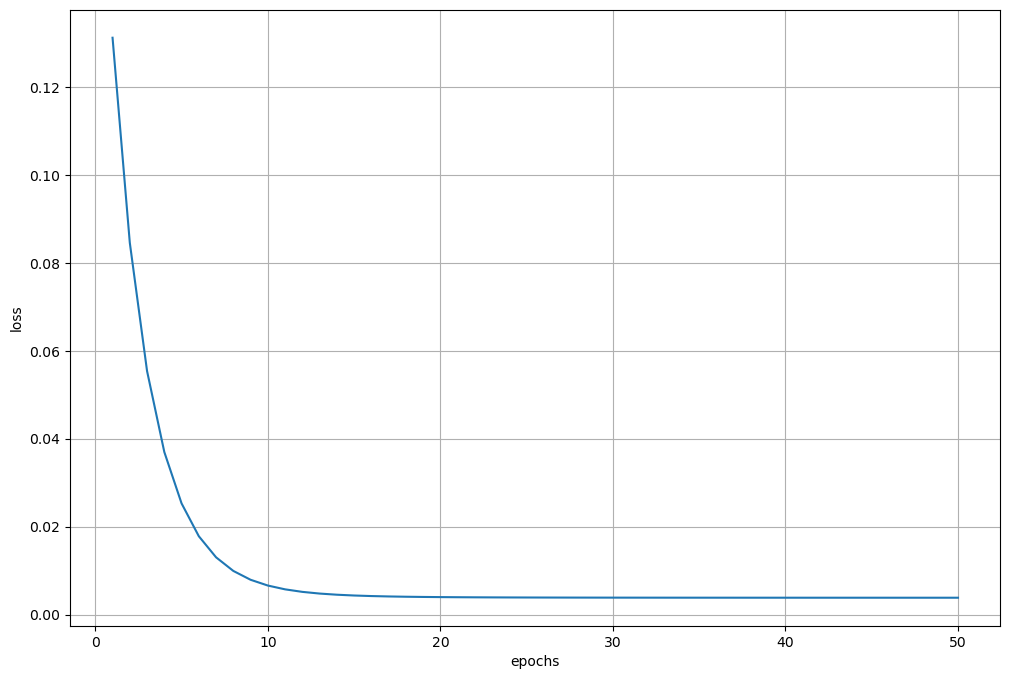

In [27]:
epochs = np.arange(1,51)
plt.plot(epochs, history)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid();

**Task**: Lets also confirm that the optimization converged on the correct `theta` parameters.  You won't be able to use `polyfit` this time
since we have more than 1 feature.  Instead use a `scikit-lear` `LinearRegression` model to fit the data.  Remember not to include the dummy
parameter in your data for fitting by `scikit-learn` (or alternatively,
read about the `fit_intercept` parameter which is normally set to True, but
could be used instead here).

Confirm that you got about the same intercept and coefficients in your
gradient descent that `scikit-learn` linear regression reports.

**Hint**: The fit should be pretty good for your optomization, though feel
free to increase the number of iterations and/or modify the learning rate to
improve it a bit if you want to get it closer to `scikit-learn` results.

In [28]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x[:,1:], y_true)

print(model.intercept_)
print(model.coef_)

0.34041265957446804
[ 0.11236935 -0.00940543 -0.01395779  0.00676074]


Congratulations on finishing your assignment.  The final task only asked for notebook work to be done, but make sure that you rerun all cells in
your notebook cleanly, and create a commit and push your results back up to your GitHub classroom.

<font color='blue'>
    
**What to remember:**

- In this assignment (and the class in general) we usually refer to a dataset as having `(n, m)` size, whith $n$ input samples, each sample consisting of $m$ features.
- For this assignment, we will add a dummy feature, so our models will have $m + 1$ features to accomodate the $\theta_0$ dummy parameter that models the intercept term for our linear models.
- We will use a variable named `y_pred` to indicate the predictions made from a model, which in our formalization above is referred to as $\hat{y}$, and can be calculated
  using a simple matrix/vector dot product $X \cdot \theta$
- The true values will be referred to as `y_true` in Python, and we use the simple notation $y$ for the true values in the formalization above.
- You can think of the errors for a single sample as `error = y_pred - y_true`.  If `y_pred` and `y_true` are vectors of $n$ predictions and true values, than the vectorized difference
  of those is also of size $n$ and contains the errors or differences between each prediction and its the true value that should be predicted for the $i^{th}$ sample.
- The average of the sum of the squares of the errors is known as the mean squared error **MSE** and will be used as our loss function to measure how well on average a liner model does in predicting the true values
  of a set of data.
- The gradients with respect to some model $\theta$ can be calculated by multiplying the inputs times the errors.  The expression given above is derived by symbolically taking the
  derivative of the $L$ loss function.
- Gradient descent optimization is done by updating the `theta` parameters using infromation from the gradients, the slope of the
  function with respect to each dimension.
- Gradient descent is an iterative method, small steps of `theta` are used to follow the gradient to the minimum loss.
- Gradient steps are updated using a learning rate, often called `eta` in the literature.
